In [12]:
from azure.storage.blob import BlobServiceClient
import io, os
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import joblib

In [2]:
# Connect to Azure Blob

os.environ["AZURE_CONNECTION_STRING"] = "ENTER_YOUR_CONNECTION_STRING_HERE"

connection_str = os.getenv("AZURE_CONNECTION_STRING")
client = BlobServiceClient.from_connection_string(connection_str) 
container = client.get_container_client("flight-data") 
 
def load_blob_csv(filename, sep=","):
    blob = container.get_blob_client(filename)
    data = blob.download_blob().readall()
    return pd.read_csv(io.BytesIO(data), sep=sep)

#load data set

df = load_blob_csv("processed/flights_model_ready.csv")

df.head(1)

,price,duration_min,dep_hour,arr_hour,day_of_week,is_weekend,num_stops,airline_AirAsia,airline_GO FIRST,airline_Indigo,...,from_Mumbai,to_Chennai,to_Delhi,to_Hyderabad,to_Kolkata,to_Mumbai,dep_period_evening,dep_period_morning,dep_period_night,class_Economy
0,5953,130,18,21,1,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,1


In [3]:
# Separate features (X) from target (y) 
X = df.drop(columns=["price"]) 
y = df["price"]

In [4]:
# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42) 
print(f"Training set: {X_train.shape[0]} rows") 
print(f"Test set: {X_test.shape[0]} rows")

Training set: 240208 rows
Test set: 60053 rows


In [8]:
# Train the model 
# n_estimators=100 means 100 decision trees 

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1   
)

model.fit(X_train, y_train) 
print("Done")

Done


In [9]:
# Evaluate the model

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:,.0f}")
print(f"MAE  : {mae:,.0f}")
print(f"R²    : {r2:.3f}")


RMSE : 3,714
MAE  : 2,326
R²    : 0.973


In [10]:
train_pred = model.predict(X_train)
train_r2   = r2_score(y_train, train_pred)
test_r2    = r2_score(y_test, y_pred)

print(f"Train R² : {train_r2:.3f}")
print(f"Test  R² : {test_r2:.3f}")
print(f"Difference: {train_r2 - test_r2:.3f}")

Train R² : 0.981
Test  R² : 0.973
Difference: 0.008


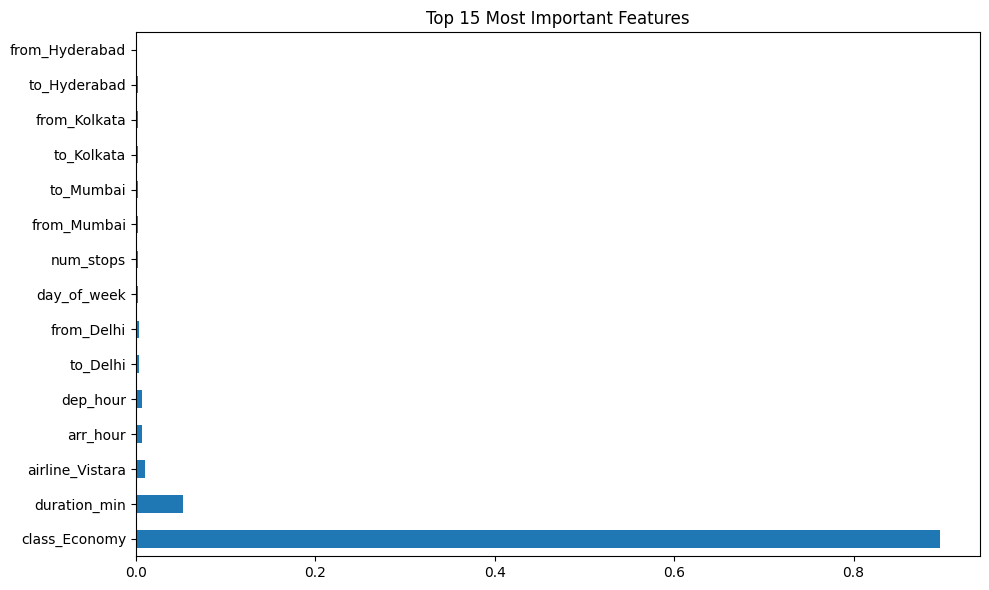

In [13]:
# Feature importance

feat_imp = pd.Series(model.feature_importances_, index=X.columns)

top_features = feat_imp.nlargest(15)

top_features.plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 15 Most Important Features"
)

plt.tight_layout()
plt.savefig("../reports/feature_importance.png", dpi=150)
plt.show()


In [14]:
# Save the model locally 
os.makedirs("../data/models", exist_ok=True)
joblib.dump(model, "../data/models/flight_price_model.pkl")
print("Saved locally")

# Upload the model to Azure Blob
with open("../data/models/flight_price_model.pkl", "rb") as f:
    blob_client = container.get_blob_client("models/flight_price_model.pkl")
    blob_client.upload_blob(f, overwrite=True)
print("Saved to Azure Blob")

Saved locally
Saved to Azure Blob
